# Citation
Sravan Pannala et al "Consistently Tuned Battery Lifetime Predictive Model of Capacity Loss, Resistance Increase, and Irreversible Thickness Growth" J. Electrochem. Soc. 171 010532 (2024)  
Section: Degradation Model Tuning Process

In [1]:
import pybamm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import dfols
import os, sys
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))))
from batfuns import *
plt.rcParams = set_rc_params(plt.rcParams)

eSOH_DIR = "./data/"
oCV_DIR = "./data/"

In [15]:
# get parameter values
parameter_values = get_parameter_values()
# define model
spm = pybamm.lithium_ion.SPM(
    {
        "SEI": "ec reaction limited",
        "loss of active material": "stress-driven",
        "lithium plating": "irreversible",
        "stress-induced diffusion": "false",
    }
)
#model internal parameters
param=spm.param
# initial conditions
ic=[1e-8,1e-7,2,1e-9,1e-9,1e-9]

## Tuning

In [4]:
# cost function
def multi_objective(model, data):
    """
    Generates cost function from model and data

        Equation 48,54,55 in paper
    

    Args:
        model : aging simulation solution output
        data : aging eSOH data

    Returns:
        weighted cost for different variables separately at all RPTs
    """    
    #Y_cyc
    variables = ["Capacity [A.h]", "n_Li", "C_n", "C_p"]
    # weights
    weights = [1,25,1,1]
    return np.concatenate([
        (np.array(model.loc[data['N_mod']][var]) - np.array(data[var])) * w
        for w,var in zip(weights,variables)
    ]
    )

# simulation lifestime aging
def simulate(x,eps_n_data,eps_p_data,SOC_0,Temp,experiment,parameter_values):
    """
    simulates aging given variables in a solver iteration

    equation 53 in paper

    Args:
        x: vector of variables for a solver iteration
        eps_n_data : negative electrode active material ratio
        eps_p_data : positive electrode active material ratio
        SOC_0 : intital SOC
        Temp : Temperature
        experiment : Aging experiment for the cell

    Returns:
        dictionary of aging simulation solution outputs
    """    
    return cycle_adaptive_simulation_V2(spm, parameter_values, experiment, SOC_0,save_at_cycles=1,drive_cycle=None)

# function to calculate prediction error
def prediction_error(x):
    """
    Generates the prediction error for a solver iteration
    Args:
        x : vector of variables for a solver iteration

    Returns:
        predict error used in solver
    """    
    cells = [1,4,10]
    try:
        out=[]
        for cell in cells:
            # load the data for each cell
            cell_no,dfe,dfe_0,dfo_0,N,N_0 = load_data(cell,eSOH_DIR,oCV_DIR)
            # get parameters to intialize the model
            eps_n_data,eps_p_data,c_rate_c,c_rate_d,dis_set,Temp,SOC_0 = init_exp(cell_no,dfe,spm,parameter_values)
            # define the cycling aging experiment
            experiment = pybamm.Experiment(
                [
                    ("Discharge at "+c_rate_d+dis_set,
                    "Rest for 5 min",
                    "Charge at "+c_rate_c+" until 4.2V", 
                    "Hold at 4.2V until C/50")
                ] *dfe.N.iloc[-1],
                termination="50% capacity",
            #     cccv_handling="ode",
            )
            # set parameters
            parameter_values.update(
                {
                    "Positive electrode LAM constant proportional term [s-1]": x[0]*ic[0],
                    "Negative electrode LAM constant proportional term [s-1]": x[1]*ic[1],
                    "Positive electrode LAM constant exponential term": x[2]*ic[2],
                    "Negative electrode LAM constant exponential term": x[2]*ic[2],
                    "Lithium plating kinetic rate constant [m.s-1]": x[3]*ic[3],
                    "Positive electrode LAM constant proportional term 2 [s-1]": x[5]*ic[5],
                    "Negative electrode LAM constant proportional term 2 [s-1]": x[4]*ic[4],
                    "Negative electrode active material volume fraction": eps_n_data,
                    "Positive electrode active material volume fraction": eps_p_data,
                    "Initial temperature [K]": 273.15+Temp,
                    "Ambient temperature [K]": 273.15+Temp,
                    "Negative electrode LAM min stress [Pa]": 0,
                    "Negative electrode LAM max stress [Pa]": 0,
                    "Positive electrode LAM min stress [Pa]": 0,
                    "Positive electrode LAM max stress [Pa]": 0,
                    "SEI kinetic rate constant [m.s-1]": 5.8561e-16,
                    "EC diffusivity [m2.s-1]": 2.4779e-19,
                    "SEI growth activation energy [J.mol-1]": 19669.2,
                    "Li plating resistivity [Ohm.m]": 30000.0,
                    "SEI resistivity [Ohm.m]": 30000.0,
                    "Initial inner SEI thickness [m]": 0e-09,
                    "Initial outer SEI thickness [m]": 5e-09,
                    "Negative electrode partial molar volume [m3.mol-1]": 7e-06,
                },
                check_already_exists=False,
            )
            # simulate the model
            model = cycle_adaptive_simulation_V2(spm, parameter_values, experiment, SOC_0,save_at_cycles=1,drive_cycle=None)
            # generate the error using cost function
            out_t =   1/len(dfe)*multi_objective(pd.DataFrame(model), dfe)
            # concatenate the error for multiple cells
            out=np.concatenate([out,out_t])
        print(f"x={x}, norm={np.linalg.norm(out)}")
    except Exception as error:
        print(error)
        out=[]
        for cell in cells:
            cell_no,dfe,dfe_0,dfo_0,N,N_0 = load_data(cell,eSOH_DIR,oCV_DIR)
            out_t = 1/len(dfe)*np.concatenate([np.array(dfe['Cap'])]*4)
            out=np.concatenate([out, out_t])
        out = 2*np.ones_like(out)
        print(f"Error")
        print(f"x={x}, norm={np.linalg.norm(out)}")
    return out

# function to intialize and run the model
def train_model():
    """
    Function to run the solver to tune the model

    We set the intital guess, upper bound, lower bound and solver options here

    Returns:
        solution output object with tuned parameters
    """    
    timer = pybamm.Timer()
    # initial guess
    x0 = np.array([1.0,1.0,1.0,1.0,-1,-1])
    # lower bound
    lower = np.array([1e-2, 1e-2, 0.51, 1e-1, -1e+2, -1e+2])
    # upper bound
    upper = np.array([1e+2, 1e+2, 1.50, 1e+1, -1e-2, -1e-2])
    # solver options
    dfo_opts = {
        "init.random_initial_directions":True,
        "init.run_in_parallel": True,
    }
    # run tuning
    soln_dfols = dfols.solve(prediction_error, x0,bounds=(lower, upper), rhoend=1e-2, user_params=dfo_opts)
    print(timer.time())
    return soln_dfols

# function to run tuning and generate tuned parameters
def sim_train(df):
    """
    Function which runs train_model and then saves the solution to a dataframe after multiplying back the initial conditions

    Args:
        df : empty data to save the solution in

    Returns:
        vector of solution variables, dataframe with solution variables
    """    
    soln_dfols = train_model()
    xsol = soln_dfols.x
    df['x_0'][0]=round(xsol[0],4)*ic[0]
    df['x_1'][0]=round(xsol[1],4)*ic[1]
    df['x_2'][0]=round(xsol[2]*ic[2],4)
    df['x_3'][0]=round(xsol[3],4)*ic[3]
    df['x_4'][0]=round(xsol[4],4)*ic[4]
    df['x_5'][0]=round(xsol[5],4)*ic[5]
    df['obj'][0]=soln_dfols.f
    return xsol,df

In [6]:
#initialize output
df_x = pd.DataFrame(columns=['x_0','x_1','x_2','x_3','x_4','x_5','obj'], index=[0])
#run tuning
x,df_x = sim_train(df_x)

CasADi - 2024-03-18 12:03:08 WARNING("The options 't0', 'tf', 'grid' and 'output_t0' have been deprecated.
The same functionality is provided by providing additional input arguments to the 'integrator' function, in particular:
 * Call integrator(..., t0, tf, options) for a single output time, or
 * Call integrator(..., t0, grid, options) for multiple grid points.
The legacy 'output_t0' option can be emulated by including or excluding 't0' in 'grid'.
Backwards compatibility is provided in this release only.") [.../casadi/core/integrator.cpp:515]


x=[ 1.  1.  1.  1. -1. -1.], norm=0.5536566021307057
x=[ 0.99804838  0.96572487  0.95264714  1.06343591 -0.99552385 -1.05034842], norm=0.5474878237169528
x=[ 1.08620172  0.98884994  1.03147643  0.99241806 -0.98327365 -1.03342032], norm=0.560358359255569
x=[ 1.01280852  1.07460936  1.00324836  1.0534535  -0.96616055 -0.98398599], norm=0.5429178450318689
x=[ 1.00967984  0.97441071  0.95723107  0.97771202 -0.92490455 -0.96413599], norm=0.5503105991870961
x=[ 1.04778628  1.00893882  0.94463879  1.00124688 -1.05381431 -0.95908337], norm=0.5416786567262623
x=[ 1.00491622  0.95101407  1.04315488  1.05062425 -1.00444732 -0.94404222], norm=0.5651924139102033
x=[ 1.05228961  1.06561183  0.8643064   1.01859099 -1.05656262 -0.95658802], norm=0.5135617737924015
x=[ 1.10378138  1.26133423  0.53140065  1.08475667 -1.10528619 -0.91833604], norm=0.28226516454567074
x=[ 1.38319517  2.01268116  0.51        2.46649562 -1.18951877 -0.94383217], norm=0.1306825866069
x=[ 3.63656403  1.97486737  0.51        2

In [7]:
# save output
df_x.to_csv("step_2_results.csv")
# print output
print(f"{df_x['x_0'][0]:0.4e},{df_x['x_1'][0]:0.4e},{df_x['x_2'][0]},{df_x['x_3'][0]:0.4e},{df_x['x_4'][0]:0.4e},{df_x['x_5'][0]:0.4e}")

## Simulate Results to Verify

In [18]:
# Plotting function
def plotcn(all_sumvars_dict,esoh_data,cell_no):
    """
    Generates plot comparing simulation and data  

    Args:
        all_sumvars_dict : dictionary of aging simulation outputs
        esoh_data : dataframe of eSOH data for 1st cell
        cell_no : string of cell number

    Returns:
        plot
    """   
    esoh_vars = ["x_100", "y_0", "C_n", "C_p", "Capacity [A.h]", "Loss of lithium inventory [%]"]
    all_sumvars_dict["C_n_loss"] = (all_sumvars_dict["C_n"][0]-all_sumvars_dict["C_n"])/all_sumvars_dict["C_n"][0]*100
    all_sumvars_dict["C_p_loss"] = (all_sumvars_dict["C_p"][0]-all_sumvars_dict["C_p"])/all_sumvars_dict["C_p"][0]*100
    esoh_data["C_n_loss"] = (esoh_data["C_n"][0]-esoh_data["C_n"])/esoh_data["C_n"][0]*100
    esoh_data["C_p_loss"] = (esoh_data["C_p"][0]-esoh_data["C_p"])/esoh_data["C_p"][0]*100
    fig, axes = plt.subplots(3,2,figsize=(7,7))
    for k, name in enumerate(esoh_vars):
        ax = axes.flat[k]
        ax.plot(all_sumvars_dict["Cycle number"],all_sumvars_dict[name],"ro")
        ax.plot(esoh_data["N"],esoh_data[name],"kx")
        ax.set_title(split_long_string(name))
        if k ==2 or k==3:
            ax.set_ylim([3,6.2])
        if k>3:
            ax.set_xlabel("Cycle number")
    fig.legend(["Sim"] + ["Data"], 
           loc="lower center",bbox_to_anchor=[0.5,-0.02], ncol=1, fontsize=11)
    fig.suptitle(f"Cell {cell_no}")
    fig.tight_layout()
    return fig

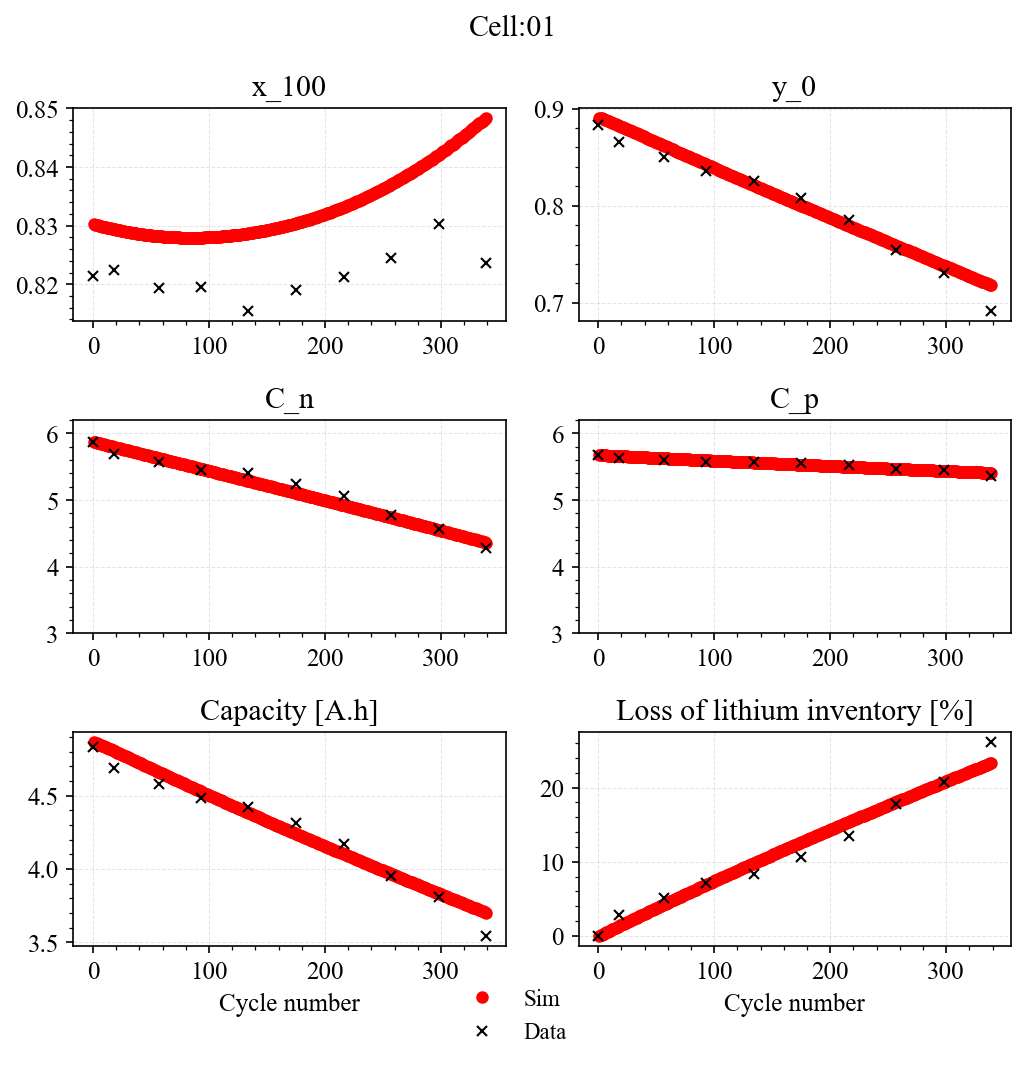

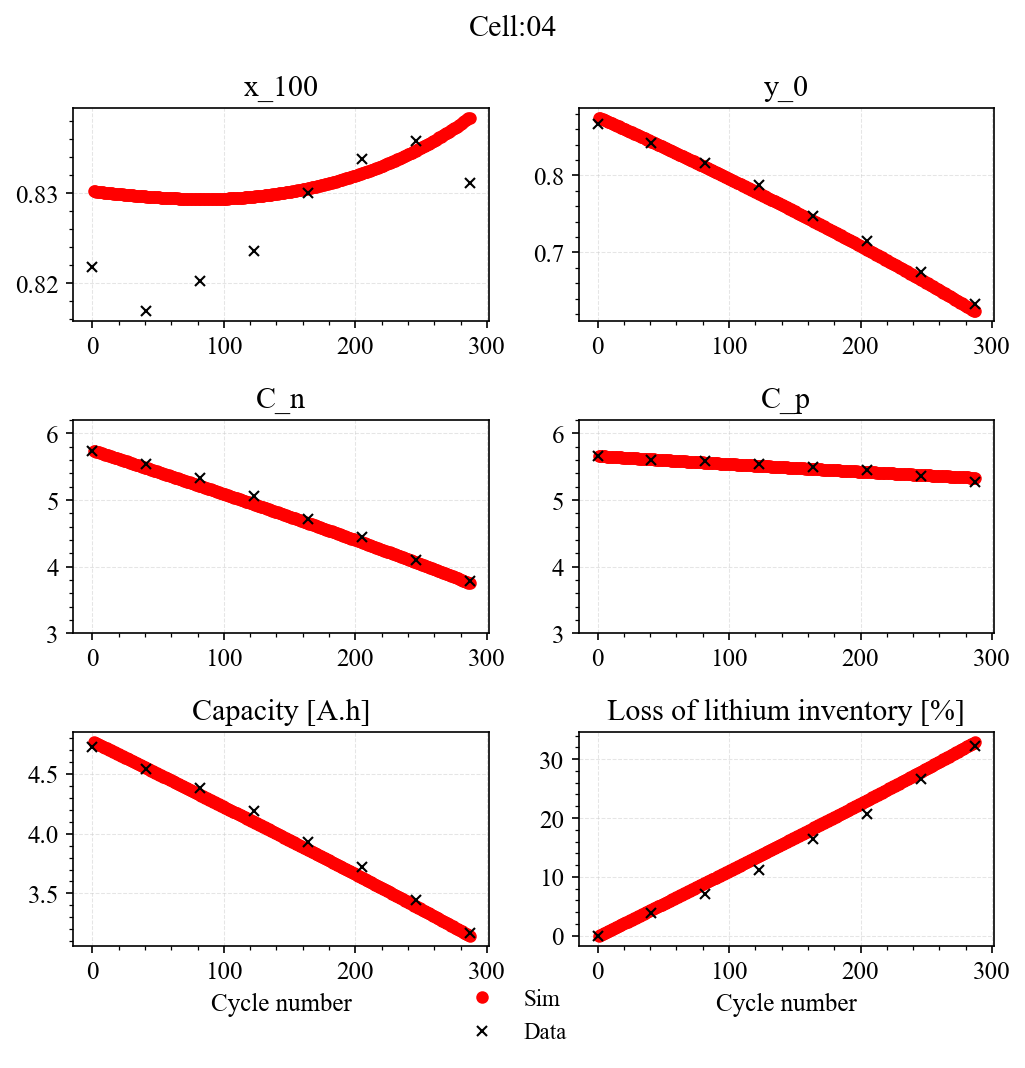

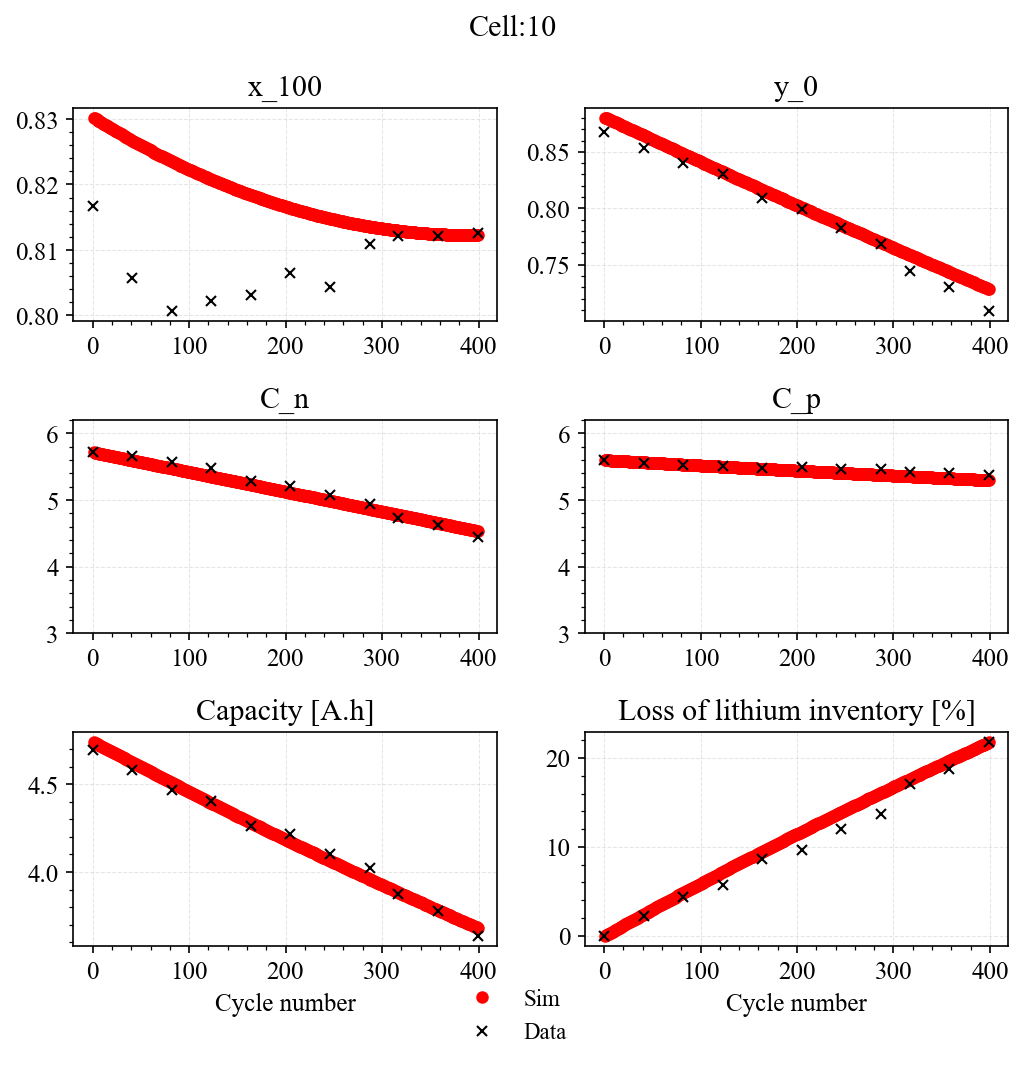

In [19]:
# Run simulation and plot tuning results
for cell in [1,4,10]:
    cell_no,dfe,dfe_0,dfo_0,N,N_0 = load_data(cell,eSOH_DIR,oCV_DIR)
    eps_n_data,eps_p_data,c_rate_c,c_rate_d,dis_set,Temp,SOC_0 = init_exp(cell_no,dfe,spm,parameter_values)
    # print(f"Cell: {cell_no}")
    experiment = pybamm.Experiment(
        [
            ("Discharge at "+c_rate_d+dis_set,
            "Rest for 5 min",
            "Charge at "+c_rate_c+" until 4.2V", 
            "Hold at 4.2V until C/100")
        ] *dfe.N.iloc[-1],
        termination="50% capacity",
    #     cccv_handling="ode",
    )
    parameter_values.update(
        {
            "Positive electrode LAM constant proportional term [s-1]": x[0]*ic[0],
            "Negative electrode LAM constant proportional term [s-1]": x[1]*ic[1],
            "Positive electrode LAM constant exponential term": x[2]*ic[2],
            "Negative electrode LAM constant exponential term": x[2]*ic[2],
            "Lithium plating kinetic rate constant [m.s-1]": x[3]*ic[3],
            "Positive electrode LAM constant proportional term 2 [s-1]": x[5]*ic[5],
            "Negative electrode LAM constant proportional term 2 [s-1]": x[4]*ic[4],
            "Negative electrode active material volume fraction": eps_n_data,
            "Positive electrode active material volume fraction": eps_p_data,
            "Initial temperature [K]": 273.15+Temp,
            "Ambient temperature [K]": 273.15+Temp,
            "Negative electrode LAM min stress [Pa]": 0,
            "Negative electrode LAM max stress [Pa]": 0,
            "Positive electrode LAM min stress [Pa]": 0,
            "Positive electrode LAM max stress [Pa]": 0,
            # using results from step 1 here:
            "SEI kinetic rate constant [m.s-1]": 5.8561e-16,
            "EC diffusivity [m2.s-1]": 2.4779e-19,
            "SEI growth activation energy [J.mol-1]": 19669.2,
            "Li plating resistivity [Ohm.m]": 30000.0,
            "SEI resistivity [Ohm.m]": 30000.0,
            "Initial inner SEI thickness [m]": 0e-09,
            "Initial outer SEI thickness [m]": 5e-09,
            "Negative electrode partial molar volume [m3.mol-1]": 7e-06,
        },
        check_already_exists=False,
    )
    # print(f"Model")
    sol_out = cycle_adaptive_simulation_V2(spm, parameter_values, experiment, SOC_0,save_at_cycles=1,drive_cycle=None)
    fig = plotcn(sol_out,dfe,cell_no);